In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd: Handles tabular data, like Excel or CSV files, using a DataFrame.

np: ast numerical computing with arrays, calculations, missing values such as np.nan, and mathematical operations.

plt: plot graphs.

ColumnTransformer applies different preprocessing steps to different columns.

SimpleImputer fills missing values instead of letting many ML models fail on blank entries.

LogisticRegression predicts the probability of a class, then converts that probability into a predicted label.

for logistic regression-reports precision, recall, F1-score, and support for every class.

confusion_matrix(y_test, y_pred): counts correct and incorrect predictions by actual class and predicted class.

ConfusionMatrixDisplay: turns that matrix into a readable visual chart.

train_test_split: This divides data into training and test portions.

A Pipeline joins several sequential steps-such as filling missing values, scaling, and modelling-into one object. 

OneHotEncoder converts non-numerical categories into numeric binary columns.

StandardScaler standardizes numeric values so features are measured on a comparable scale.

#### we will treat zero blood pressure and cholesterol readings as missing, match it with the clean values from the eda.

In [23]:
df_clean = pd.read_csv("Heart_dataset")
df_clean = df_clean.replace([" ", "NA", "N/A", ""], np.nan)

for column in ["RestingBP", "Cholesterol"]:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")
        df_clean[column] = df_clean[column].replace(0, np.nan)

print("Dataset shape:", df_clean.shape)
display(df_clean.head())
print("\nMissing values by column:")
display(df_clean.isna().sum())

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0



Missing values by column:


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

errors="coerce": if a value cannot be converted to a number, replace it with NaN instead of raising an error.

#### HeartDisease is what the models will predict. All other columns are features used to make the prediction.

In [24]:
target_column = "HeartDisease"

X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

if y.isna().any():
    raise ValueError("The target column contains missing values. Clean it before training.")

print("Feature columns:", list(X.columns))
print("\nTarget values:")
print(y.value_counts().sort_index())

Feature columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Target values:
HeartDisease
0    410
1    508
Name: count, dtype: int64


X is a DataFrame containing the predictor columns. The model will use these patient details to find patterns. 
y is a Pandas Series, not a DataFrame. It contains the correct answer for every patient record.

## USING TRAIN-TEST-SPLIT 
TRAINING:70-TESTING-30

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 642
Testing rows: 276


The model will learn from the training set and then be evaluated on the untouched test set.

random_state=42
This fixes the random splitting pattern. 

stratify=y
It tells Scikit-learn to preserve approximately the same proportion of 0 and 1 labels in both the training and test sets.

## preprocessing
numerical features are standardized.
categorical features have the most frequesnt training value.


In [26]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessing = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessing, numeric_columns),
    ("categorical", categorical_preprocessing, categorical_columns),
])

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


syntax of pipeline:
Pipeline([
    ("step_name_1", transformer_1),
    ("step_name_2", transformer_2),
])
follows ordered steps for preprocessing.

syntax of coulmntransformer:
ColumnTransformer([
    ("transformer_name", transformer, list_of_columns),
])

1. Numeric data: fill missing values, then scale values.
2. Categorical data: fill missing values, then convert text categories into numbers.
3. ColumnTransformer() applies a different transformation pipeline to different selected columns, then joins the results side by side.

### For each model, the function fits the model on the training data and evaluates predictions on the testing data. It prints accuracy, a classification report, and a confusion matrix.

code for evaulation function:

In [27]:
def evaluate_model(model, model_name, threshold=None):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    if threshold is not None:
        predictions = (predictions >= threshold).astype(int)

    labels = sorted(y.unique())
    accuracy = accuracy_score(y_test, predictions)

    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f} ({accuracy:.2%})")
    print("\nClassification report:")
    print(classification_report(
        y_test,
        predictions,
        labels=labels,
        zero_division=0,
    ))
    print("Confusion matrix (rows = actual, columns = predicted):")
    print(confusion_matrix(y_test, predictions, labels=labels))

    label_names = ["Not diseased", "Diseased"]
    matrix = confusion_matrix(y_test, predictions, labels=labels)
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=label_names,
    ).plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return accuracy

- classification_report() produces performance measures for each class.
- y_test: actual labels.
- predictions: model-generated labels.
- labels=labels: ensures classes appear in the order [0, 1].
- zero_division=0: if the model makes no predictions for a class, a metric could involve division by zero. This setting outputs 0 instead of a warning/error.

- Precision: Of all patients predicted as diseased, how many really were diseased?
- Recall: Of all truly diseased patients, how many did the model identify?
- F1-score: A balance between precision and recall.
Support: Number of actual cases of that class in the test set.

Logistic Regression is designed for classification. It estimates the probability of each class and predicts the most likely class.


Logistic Regression
Accuracy: 0.8804 (88.04%)

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       123
           1       0.89      0.90      0.89       153

    accuracy                           0.88       276
   macro avg       0.88      0.88      0.88       276
weighted avg       0.88      0.88      0.88       276

Confusion matrix (rows = actual, columns = predicted):
[[106  17]
 [ 16 137]]


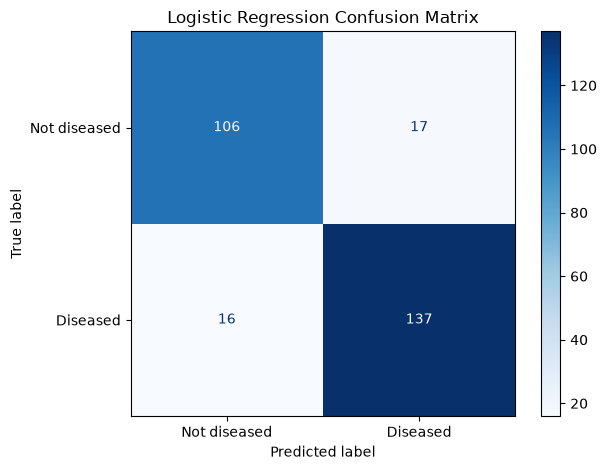

In [28]:
logistic_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_accuracy = evaluate_model(
    logistic_pipeline,
    "Logistic Regression",
)

In [29]:

print(f"Logistic Regression: {logistic_accuracy:.4f} ({logistic_accuracy:.2%})")


Logistic Regression: 0.8804 (88.04%)


# streamlit

In [30]:
import pickle

In [31]:
filename= "heart_disease_model.sav"
pickle.dump(logistic_pipeline, open(filename, 'wb'))


In [32]:
loaded_model=pickle.load(open(filename, 'rb'))
